# Welcome to HiMaLAYAS Quickstart

This notebook provides a beginner-friendly, end-to-end example of **Hierarchical Matrix Layout and Annotation Software (HiMaLAYAS)** for post hoc enrichment-based annotation and visualization of hierarchically clustered matrices.

In this quickstart, we recreate the parent-level yeast analysis shown in **Figure 1B** of the HiMaLAYAS manuscript. HiMaLAYAS is applied to a preprocessed **yeast genetic interaction profile similarity matrix** (Costanzo _et al_., 2016), and dendrogram-defined clusters are annotated with **Gene Ontology Biological Process** (**GO BP**; Ashburner _et al_., 2000) terms.

You will learn how to:
- Load a matrix and GO BP annotations
- Run the Figure 1B parent-level reference analysis
- Plot an annotated matrix, companion colorbars, and a condensed hierarchy view

Expected input files in `data`:
- `gi_pcc_sampled.tsv`
- `go_bp_name_to_orfs.json`

For the Figure 1C zoomed view, see `quickstart_advanced.ipynb`.


---

## Setup

Enable inline plotting and define the figure export paths.


In [1]:
# Enable inline plotting for notebooks
%matplotlib inline
# Keep inline notebook figures lightweight for GitHub and Binder rendering.
%config InlineBackend.rc = {'figure.dpi': 72}

In [2]:
from pathlib import Path
import warnings

warnings.filterwarnings(
    "ignore",
    message=r"Dropped .* annotations after matrix filtering.*",
    category=RuntimeWarning,
)

---

## Load GO BP Annotations

Load GO BP term-to-ORF mappings.


GO BP terms loaded: 1,095
Min term size: 5
Max term size: 243
Unique ORFs across all terms: 4,927


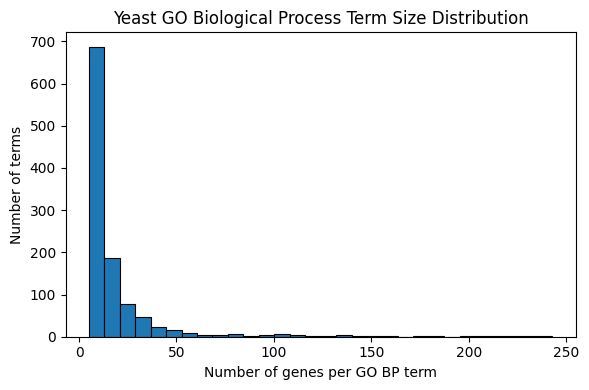

In [3]:
# Loads pre-filtered GO BP annotations and visualizes term sizes.
import json

import matplotlib.pyplot as plt

DATA_DIR = Path("data")
GO_BP_PATH = DATA_DIR / "go_bp_name_to_orfs.json"

# Load GO Biological Process term -> ORF mapping (already filtered upstream)
with GO_BP_PATH.open("r", encoding="utf-8") as fh:
    go_bp = json.load(fh)

# Compute term sizes and global ORF coverage
term_sizes = [len(set(orfs)) for orfs in go_bp.values()]
all_orfs = {orf for orfs in go_bp.values() for orf in orfs}

# Summary statistics reported in the manuscript
print(f"GO BP terms loaded: {len(term_sizes):,}")
print(f"Min term size: {min(term_sizes)}")
print(f"Max term size: {max(term_sizes)}")
print(f"Unique ORFs across all terms: {len(all_orfs):,}")

# Histogram of GO BP term sizes
plt.figure(figsize=(6, 4))
plt.hist(
    term_sizes,
    bins=30,
    edgecolor="black",
    linewidth=0.8,
)
plt.xlabel("Number of genes per GO BP term")
plt.ylabel("Number of terms")
plt.title("Yeast GO Biological Process Term Size Distribution")
plt.tight_layout()
plt.show()

# Optional: save figures locally (Binder storage is temporary).
SAVE_FIGURES = False

if SAVE_FIGURES:
    Path("outputs").mkdir(exist_ok=True)
    plt.savefig("outputs/quickstart_go_bp_term_sizes.png", dpi=300, bbox_inches="tight")
# Use Helvetica globally for notebook figures.
plt.rcParams["font.family"] = "Helvetica"
plt.rcParams["font.sans-serif"] = ["Helvetica", "Arial", "DejaVu Sans"]

---

## Load the Matrix

Load the genetic interaction profile similarity matrix. Rows and columns should have identical ORF labels.


In [4]:
import pandas as pd

MATRIX_PATH = DATA_DIR / "gi_pcc_sampled.tsv"

# Load genetic interaction profile similarity matrix (ORF × ORF)
DF_GI_PCC = pd.read_csv(
    MATRIX_PATH,
    sep="\t",
    index_col=0,
)

# Sanity checks
print(f"Matrix shape: {DF_GI_PCC.shape[0]:,} × {DF_GI_PCC.shape[1]:,}")
print(f"Row/column labels identical: {DF_GI_PCC.index.equals(DF_GI_PCC.columns)}")
print(f"Value range: [{DF_GI_PCC.min().min():.3f}, {DF_GI_PCC.max().max():.3f}]")

Matrix shape: 1,053 × 1,053
Row/column labels identical: True
Value range: [-0.317, 0.845]


---

## Run the Figure 1B Reference Analysis

Cluster the full yeast genetic interaction profile similarity matrix and test GO BP enrichment using the fixed reference settings from the manuscript.


In [5]:
import himalayas
from himalayas import Analysis, Annotations, Matrix

print(f"HiMaLAYAS version: {himalayas.__version__}\n")

REFERENCE_CONFIG = dict(
    linkage_method="ward",
    linkage_metric="euclidean",
    linkage_threshold=16,
    optimal_ordering=True,
    min_cluster_size=30,
)
MIN_OVERLAP = 2
QVAL_CUTOFF = 0.05

# Build core objects
matrix = Matrix(DF_GI_PCC)
annotations = Annotations(
    go_bp,
    matrix,
)

# Run clustering + enrichment
analysis = (
    Analysis(matrix, annotations)
    .cluster(**REFERENCE_CONFIG)
    .enrich(min_overlap=MIN_OVERLAP)
    .finalize(
        col_cluster=True,
    )
)
results = analysis.results
# Keep significant terms
results_sig = results.filter(f"qval <= {QVAL_CUTOFF}")

cluster_labels = results_sig.cluster_labels(
    rank_by="q",
    label_mode="top_term",
)

print(f"All enriched rows: {len(results.df):,}")
print(f"Significant cluster-term pairs (q<=0.05): {len(results_sig.df):,}")
print(cluster_labels)

HiMaLAYAS version: 0.0.16

All enriched rows: 709
Significant cluster-term pairs (q<=0.05): 331
   cluster                                              label          pval  \
0        1                    GPI anchor biosynthetic process  3.222730e-12   
1        2                         vesicle-mediated transport  1.237408e-26   
2        3                     mRNA splicing, via spliceosome  2.829998e-16   
3        4                            cytoplasmic translation  8.925220e-15   
4        5  mitochondrial respiratory chain complex IV ass...  1.794876e-19   
5        6                                    DNA replication  1.798541e-42   
6        7                                      cell division  2.138848e-20   

           qval         score    n  \
0  8.788137e-11  8.788137e-11  148   
1  4.386613e-24  4.386613e-24   92   
2  1.433192e-14  1.433192e-14  263   
3  3.954988e-13  3.954988e-13  358   
4  1.590709e-17  1.590709e-17   78   
5  1.275166e-39  1.275166e-39   52   
6  2.

---

## Plot the Annotated Matrix

Render the clustered yeast genetic interaction profile similarity matrix with parent-cluster labels and the enrichment significance track.


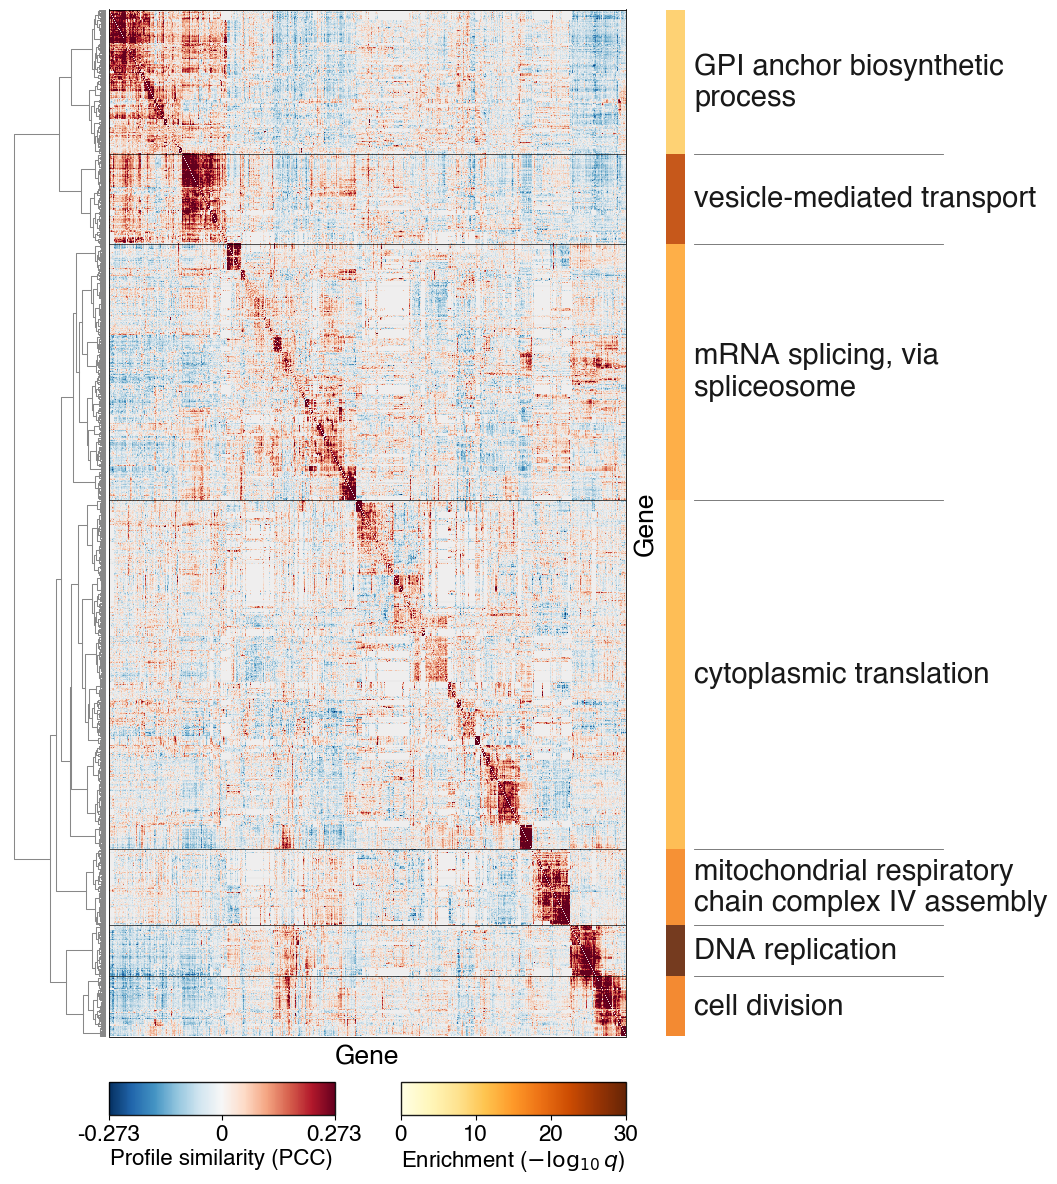

In [6]:
import numpy as np
from matplotlib.colors import Normalize
from himalayas.plot import Plotter

LABEL_COLOR = "black"
BACKGROUND_COLOR = "white"
DENDRO_COLOR = "#888888"
FONT = "DejaVu Sans"
MATRIX_CMAP = "RdBu_r"
MATRIX_LW = 0.6
ENRICHMENT_CMAP = "YlOrBr"

vals = matrix.values
mask = np.isfinite(vals) & (vals != 0)
vlim = float(np.percentile(np.abs(vals[mask]), 99))

plotter = (
    Plotter(results_sig)
    .set_background(color=BACKGROUND_COLOR)
    .plot_dendrogram(
        axes=[0.06, 0.16, 0.09, 0.79],
        data_pad=0.35,
        color=DENDRO_COLOR,
        linewidth=0.75,
    )
    .set_figure(
        figsize=(11, 13),
        subplots_adjust={"left": 0.15, "right": 0.62, "bottom": 0.16, "top": 0.95},
    )
    .plot_matrix(
        cmap=MATRIX_CMAP,
        center=0,
        vmin=-vlim,
        vmax=vlim,
        outer_lw=MATRIX_LW,
        outer_color=LABEL_COLOR,
    )
    .plot_matrix_axis_labels(
        xlabel="Gene",
        ylabel="Gene",
        fontsize=19,
        font=FONT,
        fontweight="normal",
        color=LABEL_COLOR,
        xlabel_pad=6.0,
        ylabel_pad=0.011,
    )
    .set_label_panel(
        axes=[0.62, 0.16, 0.36, 0.79],
        gutter_color=BACKGROUND_COLOR,
        text_pad=0.012,
    )
    .plot_cluster_labels(
        rank_by="q",
        label_mode="top_term",
        max_words=30,
        wrap_text=True,
        wrap_width=26,
        overflow="wrap",
        font=FONT,
        fontsize=21,
        color=LABEL_COLOR,
        skip_unlabeled=False,
        label_fields=("label",),
        omit_words=(),
        boundary_color=LABEL_COLOR,
        boundary_lw=MATRIX_LW,
        boundary_alpha=0.8,
        label_sep_xmin=None,
        label_sep_xmax=0.8,
        label_sep_color=LABEL_COLOR,
        label_sep_lw=MATRIX_LW,
        label_sep_alpha=0.6,
    )
    .plot_cluster_bar(
        norm=Normalize(0, 30),
        name="sigbar",
        title="Enrichment",
        width=0.05,
        left_pad=0.07,
        right_pad=0.01,
    )
    .add_colorbar(
        name="matrix",
        cmap=MATRIX_CMAP,
        norm=Normalize(-vlim, vlim),
        label="Profile similarity (PCC)",
        ticks=[-vlim, 0, vlim],
    )
    .add_colorbar(
        name="enrichment",
        cmap=ENRICHMENT_CMAP,
        norm=Normalize(0, 30),
        label=r"Enrichment ($-\log_{10}q$)",
        ticks=[0, 10, 20, 30],
    )
    .plot_colorbars(
        ncols=2,
        height=0.025,
        gap=0.035,
        label_pad=2.0,
        hpad=0.06,
        vpad=0.00,
        fontsize=16,
        font=FONT,
        color=LABEL_COLOR,
        border_color=LABEL_COLOR,
        border_width=1.0,
        border_alpha=0.9,
        tick_decimals=3,
    )
)

plotter.show()

# Optional: save figures locally (Binder storage is temporary).
SAVE_FIGURES = False

if SAVE_FIGURES:
    Path("outputs").mkdir(exist_ok=True)
    plotter.save("outputs/quickstart_matrix.png", dpi=300, bbox_inches="tight")

---

## Condensed Dendrogram

Summarize the same parent-level hierarchy as a condensed dendrogram with cluster labels and the enrichment significance track.

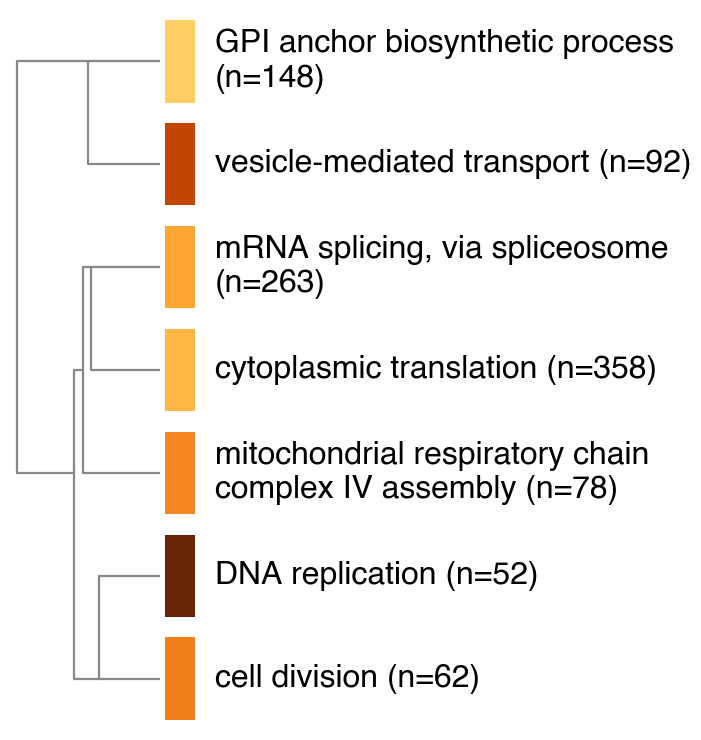

In [7]:
from himalayas.plot import plot_dendrogram_condensed

MATRIX_CONDENSED_LW = 1.6

full_condensed = plot_dendrogram_condensed(
    results_sig,
    rank_by="q",
    label_mode="top_term",
    figsize=(5, 8),
    dendrogram_width=0.3,
    sigbar_cmap=ENRICHMENT_CMAP,
    sigbar_width=0.06,
    sigbar_height=0.8,
    sigbar_min_logp=0.0,
    sigbar_max_logp=30.0,
    font=FONT,
    fontsize=23,
    max_words=40,
    wrap_text=True,
    wrap_width=34,
    overflow="ellipsis",
    omit_words=(),
    label_fields=("label", "n"),
    label_color=LABEL_COLOR,
    label_left_pad=0.04,
    dendrogram_color=DENDRO_COLOR,
    dendrogram_lw=MATRIX_CONDENSED_LW,
    background_color=BACKGROUND_COLOR,
)
full_condensed.show()

# Optional: save figures locally (Binder storage is temporary).
SAVE_FIGURES = False

if SAVE_FIGURES:
    Path("outputs").mkdir(exist_ok=True)
    full_condensed.save(
        "outputs/quickstart_condensed.png", dpi=300, bbox_inches="tight", pad_inches=0.02
    )